In [4]:
import pandas as pd

ice = pd.read_csv('SeaIce.txt', delim_whitespace=True)
print('shape:', ice.shape)
print(ice)


shape: (424, 6)
     year  mo data_type region  extent   area
0    1979   1   Goddard      N   15.54  12.33
1    1980   1   Goddard      N   14.96  11.85
2    1981   1   Goddard      N   15.03  11.82
3    1982   1   Goddard      N   15.26  12.11
4    1983   1   Goddard      N   15.10  11.92
..    ...  ..       ...    ...     ...    ...
419  2009  12   Goddard      N   12.51  10.25
420  2010  12   Goddard      N   12.02  10.08
421  2011  12   Goddard      N   12.40  10.28
422  2012  12   Goddard      N   12.20  10.11
423  2013  12   NRTSI-G      N   12.38  10.48

[424 rows x 6 columns]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19164\976240361.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ice = pd.read_csv('SeaIce.txt', delim_whitespace=True)


In [6]:
ice2 = ice[ice['data_type'] != '-9999']

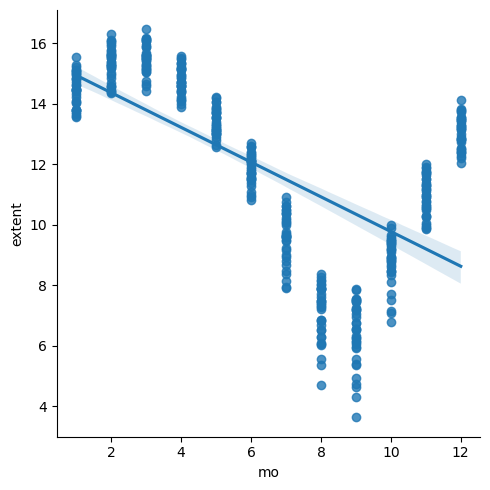

In [9]:
import seaborn as sns

sns.lmplot(x="mo", y="extent", data=ice2)


month_means tính được:
mo
1     6.394885e-15
2    -6.241921e-15
3    -3.552714e-15
4     1.507366e-14
5    -7.333816e-15
6    -1.040438e-14
7    -2.030122e-15
8     3.248195e-15
9     2.030122e-16
10   -3.907985e-15
11   -6.266592e-15
12    5.938107e-15
Name: extent, dtype: float64
Các chỉ số index trong month_means:
Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int64', name='mo')


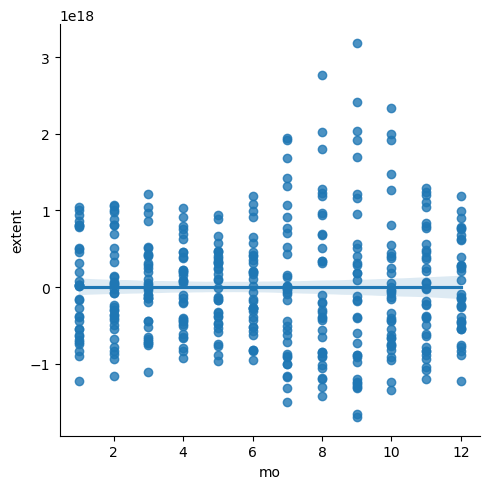

In [17]:
import matplotlib.pyplot as plt

# 4. Tính toán giá trị trung bình (month_means) theo từng tháng ('mo')
month_means = ice2.groupby('mo')['extent'].mean()

# Debug: Kiểm tra các chỉ số tháng trong month_means
print("month_means tính được:")
print(month_means)

# Kiểm tra index của month_means
print("Các chỉ số index trong month_means:")
print(month_means.index)
for i in range(12):  
    if (i + 1) in month_means.index:  # Kiểm tra nếu tháng i+1 nằm trong index của month_means
        ice2.loc[ice2['mo'] == i + 1, 'extent'] = 100 * (
            ice2.loc[ice2['mo'] == i + 1, 'extent'] - month_means[i + 1]
        ) / month_means.mean()
    else:
        print(f"Tháng {i+1} không tìm thấy trong month_means")

# 6. Vẽ biểu đồ với seaborn
sns.lmplot(x="mo", y="extent", data=ice2)

# Hiện biểu đồ
plt.show()

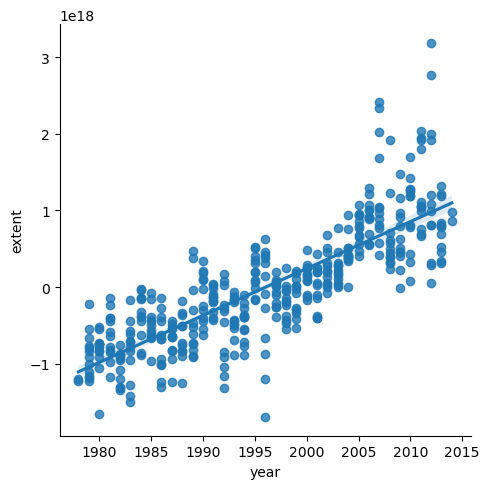

In [19]:
sns.lmplot(x="year", y="extent", data=ice2)


In [20]:
from sklearn. linear_model import LinearRegression
est = LinearRegression(fit_intercept = True)

In [25]:
x = ice2[['year']]
y = ice2[['extent']]
est.fit(x, y)
print("Coefficients:", est.coef_)
print("Intercept:", est.intercept_)


Coefficients: [[6.11853301e+16]]
Intercept: [-1.22128384e+20]


In [27]:
from sklearn import metrics

# Dự đoán với mô hình hồi quy
y_hat = est.predict(x)

# In kết quả MSE và R^2
print("MSE:", metrics.mean_squared_error(y_hat, y))
print("R^2:", metrics.r2_score(y_hat, y))

# In phương sai của y
print("var:", y.var())


MSE: 1.9247473002885007e+35
R^2: 0.506787038210026
var: extent    5.841056e+35
dtype: float64


In [32]:
x = ice2[['year']]
y = ice2[['extent']]

# 3. Tạo mô hình Linear Regression và huấn luyện
model = LinearRegression()
model.fit(x, y)
import pandas as pd
x_new = pd.DataFrame([[2025]], columns=["year"])
y_hat = model.predict(x_new)

# Thêm chuyển đổi vào công thức theo thông tin của bạn
m = 1  # Tháng 1 (January)
y_hat = (y_hat * ice2['extent'].mean() / 100) + ice2['extent'].mean()

# In kết quả dự đoán
print("Prediction of extent for January 2025 (in millions of square km):", y_hat)

Prediction of extent for January 2025 (in millions of square km): [[-6.44941563e+16]]
